In [530]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Enlace a Gitbhub con el proyecto completo: [Proyecto Data Wizards](https://github.com/MetalMaxALIZ/Proyecto_Data_Wizards)

# Index
1. [33. Cargar y Verificar Datos](#33-Cargar-y-Verificar-Datos)
2. [34. Limpieza de Datos](#34-Limpieza-de-Datos)
3. [35. Exploración de Distribuciones](#35-Exploracion-de-Distribuciones)
4. [36. Matriz de Correlación y Heatmap](#36-Matriz-de-Correlacion-y-Heatmap)
5. [37. Patrones Temporales](#37-Patrones-Temporales)
6. [38. Segmentación de Usuarios (Descriptivo)](#38-Segmentacion-de-Usuarios-(Descriptivo))
7. [39. Ingeniería de Features (Creativa y Requerida)](#39-Ingenieria-de-Features-(Creativa-y-Requerida))

## 33. Cargar y Verificar Datos

In [531]:
# Cargar datos en CSV

artistas_rendimiento = pd.read_csv("tb_artistas_rendimiento.csv", sep=";")
canciones_estadisticas = pd.read_csv("tb_canciones_estadisticas.csv", sep=";")
generos_por_temporada = pd.read_csv("tb_generos_por_temporada.csv", sep=";")
perfil_oyentes = pd.read_csv("tb_perfil_oyentes.csv", sep=";")
streaming_mensual = pd.read_csv("tb_streaming_mensual.csv", sep=";")
artistas = pd.read_csv("artistas.csv")
canciones = pd.read_csv("canciones.csv")
charts_semanales = pd.read_csv("charts_semanales.csv")
eventos_temporales = pd.read_csv("eventos_temporales.csv")
generos_detallados = pd.read_csv("generos_detallados.csv")
playlist_canciones = pd.read_csv("playlist_canciones.csv")
playlists = pd.read_csv("playlists.csv")
reproducciones = pd.read_csv("reproducciones_v2.csv")
usuarios = pd.read_csv("usuarios.csv")
valoraciones = pd.read_csv("valoraciones.csv")


####  Verificacion artistas_rendimiento


In [532]:
print(artistas_rendimiento.shape)

(200, 18)


In [533]:
print(artistas_rendimiento.dtypes)

artista_id                        int64
nombre_artistico                 object
genero_principal                 object
pais_origen                      object
anio_debut                        int64
seguidores                        int64
verificado                        int64
sello_discografico               object
num_canciones                     int64
num_canciones_en_chart            int64
total_streams                     int64
streams_promedio_por_cancion    float64
puntuacion_media                float64
bailabilidad_media              float64
energia_media                   float64
mejor_posicion_chart              int64
total_semanas_chart               int64
num_playlists_total               int64
dtype: object


In [534]:
artistas_rendimiento.head()

,artista_id,nombre_artistico,genero_principal,pais_origen,anio_debut,seguidores,verificado,sello_discografico,num_canciones,num_canciones_en_chart,total_streams,streams_promedio_por_cancion,puntuacion_media,bailabilidad_media,energia_media,mejor_posicion_chart,total_semanas_chart,num_playlists_total
0,1,La Casa Azul,rock,España,1953,2446340,0,Independiente,8,7,13778,1722.25,3.77,0.42,0.73,3,16,31
1,2,Recycled J,rap,España,1967,15150607,0,Columbia Records,12,12,36218,3018.17,3.85,0.77,0.81,1,29,50
2,3,El Guincho,r&b,España,1961,6683728,1,Sony Music,11,11,19504,1773.09,3.75,0.64,0.59,1,30,39
3,4,Los Secretos,pop,España,1961,4664712,1,TuneCore,6,5,11227,1871.17,3.38,0.69,0.66,4,12,19
4,5,Duncan Dhu,clasica,España,1953,948124,1,Astralwerks,7,6,24190,3455.71,3.65,0.17,0.26,13,18,34


In [535]:
artistas_rendimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   artista_id                    200 non-null    int64  
 1   nombre_artistico              200 non-null    object 
 2   genero_principal              200 non-null    object 
 3   pais_origen                   200 non-null    object 
 4   anio_debut                    200 non-null    int64  
 5   seguidores                    200 non-null    int64  
 6   verificado                    200 non-null    int64  
 7   sello_discografico            200 non-null    object 
 8   num_canciones                 200 non-null    int64  
 9   num_canciones_en_chart        200 non-null    int64  
 10  total_streams                 200 non-null    int64  
 11  streams_promedio_por_cancion  200 non-null    float64
 12  puntuacion_media              200 non-null    float64
 13  baila

In [536]:
# Cambiamos el tipo de la columna anio_debut a DATE

artistas_rendimiento["anio_debut"] = pd.to_datetime(artistas_rendimiento["anio_debut"], format="%Y")

In [537]:
artistas_rendimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   artista_id                    200 non-null    int64         
 1   nombre_artistico              200 non-null    object        
 2   genero_principal              200 non-null    object        
 3   pais_origen                   200 non-null    object        
 4   anio_debut                    200 non-null    datetime64[ns]
 5   seguidores                    200 non-null    int64         
 6   verificado                    200 non-null    int64         
 7   sello_discografico            200 non-null    object        
 8   num_canciones                 200 non-null    int64         
 9   num_canciones_en_chart        200 non-null    int64         
 10  total_streams                 200 non-null    int64         
 11  streams_promedio_por_cancion  20

In [538]:
artistas_rendimiento.isnull().sum()

artista_id                      0
nombre_artistico                0
genero_principal                0
pais_origen                     0
anio_debut                      0
seguidores                      0
verificado                      0
sello_discografico              0
num_canciones                   0
num_canciones_en_chart          0
total_streams                   0
streams_promedio_por_cancion    0
puntuacion_media                0
bailabilidad_media              0
energia_media                   0
mejor_posicion_chart            0
total_semanas_chart             0
num_playlists_total             0
dtype: int64

####  Verificacion canciones_estadisticas


In [539]:
print(canciones_estadisticas.shape)

(2000, 27)


In [540]:
print(canciones_estadisticas.dtypes)

cancion_id                      int64
titulo                         object
artista_id                      int64
album                          object
anio_lanzamiento                int64
duracion_seg                    int64
genero                         object
subgenero                      object
energia                       float64
bailabilidad                  float64
valencia                      float64
acusticidad                   float64
instrumentalidad              float64
tempo                           int64
volumen_db                    float64
explicito                       int64
nombre_artistico               object
seguidores                      int64
total_reproducciones            int64
reproducciones_completadas    float64
ratio_completadas             float64
puntuacion_media              float64
num_valoraciones                int64
en_chart                        int64
mejor_posicion_chart            int64
semanas_en_chart                int64
num_playlist

In [541]:
canciones_estadisticas.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,...,seguidores,total_reproducciones,reproducciones_completadas,ratio_completadas,puntuacion_media,num_valoraciones,en_chart,mejor_posicion_chart,semanas_en_chart,num_playlists
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021,339,electronica,trance,0.86,0.63,...,2272315,35,29.0,0.8286,4.00,6,1,43,1,2
1,2,Tema 2,169,Francisco Stone - Evolución,2022,134,latin,salsa,0.64,0.87,...,134889,24,18.0,0.7500,3.17,6,1,13,4,8
2,3,Tema 3,80,Francisco Stone - Nuevo,2022,123,pop,pop-urbano,0.66,0.58,...,379450,26,19.0,0.7308,3.40,10,1,4,3,6
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021,135,latin,cumbia,0.83,0.91,...,1142190,33,22.0,0.6667,4.08,12,1,26,3,7
4,5,Tema 5,108,Gabriel García - Vueltas,2022,200,pop,pop-latino,0.51,0.59,...,4236247,22,20.0,0.9091,2.71,7,1,12,1,4


In [542]:
print(canciones_estadisticas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cancion_id                  2000 non-null   int64  
 1   titulo                      2000 non-null   object 
 2   artista_id                  2000 non-null   int64  
 3   album                       2000 non-null   object 
 4   anio_lanzamiento            2000 non-null   int64  
 5   duracion_seg                2000 non-null   int64  
 6   genero                      2000 non-null   object 
 7   subgenero                   2000 non-null   object 
 8   energia                     2000 non-null   float64
 9   bailabilidad                2000 non-null   float64
 10  valencia                    2000 non-null   float64
 11  acusticidad                 2000 non-null   float64
 12  instrumentalidad            2000 non-null   float64
 13  tempo                       2000 

In [543]:
# Cambiamos el tipo de dato de 'anio_lanzamiento' a DATE
canciones_estadisticas["anio_lanzamiento"] = pd.to_datetime(canciones_estadisticas["anio_lanzamiento"], format="%Y")

In [544]:
print(canciones_estadisticas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cancion_id                  2000 non-null   int64         
 1   titulo                      2000 non-null   object        
 2   artista_id                  2000 non-null   int64         
 3   album                       2000 non-null   object        
 4   anio_lanzamiento            2000 non-null   datetime64[ns]
 5   duracion_seg                2000 non-null   int64         
 6   genero                      2000 non-null   object        
 7   subgenero                   2000 non-null   object        
 8   energia                     2000 non-null   float64       
 9   bailabilidad                2000 non-null   float64       
 10  valencia                    2000 non-null   float64       
 11  acusticidad                 2000 non-null   float64     

In [545]:
canciones_estadisticas.isnull().sum()

cancion_id                    0
titulo                        0
artista_id                    0
album                         0
anio_lanzamiento              0
duracion_seg                  0
genero                        0
subgenero                     0
energia                       0
bailabilidad                  0
valencia                      0
acusticidad                   0
instrumentalidad              0
tempo                         0
volumen_db                    0
explicito                     0
nombre_artistico              0
seguidores                    0
total_reproducciones          0
reproducciones_completadas    0
ratio_completadas             0
puntuacion_media              0
num_valoraciones              0
en_chart                      0
mejor_posicion_chart          0
semanas_en_chart              0
num_playlists                 0
dtype: int64

####  Verificacion generos_por_temporada


In [546]:
print(generos_por_temporada.shape)

(240, 9)


In [547]:
print(generos_por_temporada.dtypes)

anio                      int64
trimestre                 int64
temporada                object
genero                   object
total_streams             int64
usuarios_unicos           int64
ratio_completadas       float64
horas_escucha           float64
porcentaje_del_total    float64
dtype: object


In [548]:
generos_por_temporada.head()

,anio,trimestre,temporada,genero,total_streams,usuarios_unicos,ratio_completadas,horas_escucha,porcentaje_del_total
0,2024,4,Invierno,pop,138,134,65.22,8.54,3.33
1,2024,1,Invierno,rock,262,256,66.79,15.88,6.31
2,2024,1,Invierno,latin,245,240,71.84,15.39,5.90
3,2024,4,Invierno,indie,194,190,71.13,11.87,4.67
4,2024,4,Invierno,flamenco,126,124,76.98,7.76,3.04


In [549]:
print(generos_por_temporada.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anio                  240 non-null    int64  
 1   trimestre             240 non-null    int64  
 2   temporada             240 non-null    object 
 3   genero                240 non-null    object 
 4   total_streams         240 non-null    int64  
 5   usuarios_unicos       240 non-null    int64  
 6   ratio_completadas     240 non-null    float64
 7   horas_escucha         240 non-null    float64
 8   porcentaje_del_total  240 non-null    float64
dtypes: float64(3), int64(4), object(2)
memory usage: 17.0+ KB
None


In [550]:
# Cambiamos la columna 'anio' a tipo DATE
generos_por_temporada["anio"] = pd.to_datetime(generos_por_temporada["anio"], format="%Y")

In [551]:
print(generos_por_temporada.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   anio                  240 non-null    datetime64[ns]
 1   trimestre             240 non-null    int64         
 2   temporada             240 non-null    object        
 3   genero                240 non-null    object        
 4   total_streams         240 non-null    int64         
 5   usuarios_unicos       240 non-null    int64         
 6   ratio_completadas     240 non-null    float64       
 7   horas_escucha         240 non-null    float64       
 8   porcentaje_del_total  240 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 17.0+ KB
None


In [552]:
generos_por_temporada.isnull().sum()

anio                    0
trimestre               0
temporada               0
genero                  0
total_streams           0
usuarios_unicos         0
ratio_completadas       0
horas_escucha           0
porcentaje_del_total    0
dtype: int64

####  Verificacion perfil_oyentes


In [553]:
print(perfil_oyentes.shape)

(5000, 17)


In [554]:
print(perfil_oyentes.dtypes)

usuario_id                      int64
edad                            int64
sexo                           object
ciudad                         object
tipo_suscripcion               object
fecha_registro                 object
dispositivo_principal          object
horas_escucha_mensual           int64
total_reproducciones            int64
canciones_distintas             int64
artistas_distintos              int64
ratio_completadas             float64
modo_reproduccion_favorito     object
reproducciones_fin_semana     float64
generos_distintos               int64
genero_favorito                object
puntuacion_media_dada         float64
dtype: object


In [555]:
perfil_oyentes.head()

,usuario_id,edad,sexo,ciudad,tipo_suscripcion,fecha_registro,dispositivo_principal,horas_escucha_mensual,total_reproducciones,canciones_distintas,artistas_distintos,ratio_completadas,modo_reproduccion_favorito,reproducciones_fin_semana,generos_distintos,genero_favorito,puntuacion_media_dada
0,1,40,M,Cádiz,premium,2021-06-22,movil,32,8,8,8,0.8750,recomendacion,25.00,6,rock,4.67
1,2,32,M,Girona,premium,2022-10-07,movil,34,7,7,7,0.7143,recomendacion,28.57,6,reggaeton,3.75
2,3,30,M,Cádiz,premium,2019-05-22,tablet,62,5,5,5,0.6000,album,40.00,4,clasica,3.50
3,4,13,No_especificado,Vigo,free,2019-11-03,pc,9,10,10,10,0.5000,playlist,30.00,5,pop,4.67
4,5,30,No_especificado,Granada,free,2022-07-22,tablet,56,10,10,10,0.8000,album,40.00,5,rap,4.67


In [556]:
print(perfil_oyentes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   usuario_id                  5000 non-null   int64  
 1   edad                        5000 non-null   int64  
 2   sexo                        5000 non-null   object 
 3   ciudad                      5000 non-null   object 
 4   tipo_suscripcion            5000 non-null   object 
 5   fecha_registro              5000 non-null   object 
 6   dispositivo_principal       5000 non-null   object 
 7   horas_escucha_mensual       5000 non-null   int64  
 8   total_reproducciones        5000 non-null   int64  
 9   canciones_distintas         5000 non-null   int64  
 10  artistas_distintos          5000 non-null   int64  
 11  ratio_completadas           5000 non-null   float64
 12  modo_reproduccion_favorito  5000 non-null   object 
 13  reproducciones_fin_semana   5000 

In [557]:
# Convertimos la columna 'fecha_registro' a tipo DATE
perfil_oyentes["fecha_registro"] = pd.to_datetime(perfil_oyentes["fecha_registro"], format="%Y-%m-%d")

In [558]:
print(perfil_oyentes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   usuario_id                  5000 non-null   int64         
 1   edad                        5000 non-null   int64         
 2   sexo                        5000 non-null   object        
 3   ciudad                      5000 non-null   object        
 4   tipo_suscripcion            5000 non-null   object        
 5   fecha_registro              5000 non-null   datetime64[ns]
 6   dispositivo_principal       5000 non-null   object        
 7   horas_escucha_mensual       5000 non-null   int64         
 8   total_reproducciones        5000 non-null   int64         
 9   canciones_distintas         5000 non-null   int64         
 10  artistas_distintos          5000 non-null   int64         
 11  ratio_completadas           5000 non-null   float64     

In [559]:
perfil_oyentes.isnull().sum()

usuario_id                    0
edad                          0
sexo                          0
ciudad                        0
tipo_suscripcion              0
fecha_registro                0
dispositivo_principal         0
horas_escucha_mensual         0
total_reproducciones          0
canciones_distintas           0
artistas_distintos            0
ratio_completadas             0
modo_reproduccion_favorito    0
reproducciones_fin_semana     0
generos_distintos             0
genero_favorito               0
puntuacion_media_dada         0
dtype: int64

####  Verificacion streaming_mensual


In [560]:
print(streaming_mensual.shape)

(36, 11)


In [561]:
print(streaming_mensual.dtypes)

anio                      int64
mes                       int64
total_streams             int64
streams_completados     float64
usuarios_activos          int64
canciones_escuchadas      int64
horas_totales           float64
top_genero               object
streams_premium         float64
streams_free            float64
ratio_completadas       float64
dtype: object


In [562]:
streaming_mensual.head()

,anio,mes,total_streams,streams_completados,usuarios_activos,canciones_escuchadas,horas_totales,top_genero,streams_premium,streams_free,ratio_completadas
0,2022,1,1411,999.0,1231,995,84.71,indie,832.0,579.0,70.80
1,2022,2,1230,868.0,1090,913,75.00,r&b,736.0,494.0,70.57
2,2022,3,1450,1037.0,1258,1034,89.06,indie,852.0,598.0,71.52
3,2022,4,1350,956.0,1179,992,84.13,indie,799.0,551.0,70.81
4,2022,5,1458,1019.0,1266,1017,87.33,indie,859.0,599.0,69.89


In [563]:
print(streaming_mensual.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anio                  36 non-null     int64  
 1   mes                   36 non-null     int64  
 2   total_streams         36 non-null     int64  
 3   streams_completados   36 non-null     float64
 4   usuarios_activos      36 non-null     int64  
 5   canciones_escuchadas  36 non-null     int64  
 6   horas_totales         36 non-null     float64
 7   top_genero            36 non-null     object 
 8   streams_premium       36 non-null     float64
 9   streams_free          36 non-null     float64
 10  ratio_completadas     36 non-null     float64
dtypes: float64(5), int64(5), object(1)
memory usage: 3.2+ KB
None


In [564]:
# Cambiamos el tipo de dato de 'anio' y 'mes' a DATE
streaming_mensual["anio"] = pd.to_datetime(streaming_mensual["anio"], format="%Y")
streaming_mensual["mes"] = pd.to_datetime(streaming_mensual["mes"], format="%m")

In [565]:
print(streaming_mensual.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   anio                  36 non-null     datetime64[ns]
 1   mes                   36 non-null     datetime64[ns]
 2   total_streams         36 non-null     int64         
 3   streams_completados   36 non-null     float64       
 4   usuarios_activos      36 non-null     int64         
 5   canciones_escuchadas  36 non-null     int64         
 6   horas_totales         36 non-null     float64       
 7   top_genero            36 non-null     object        
 8   streams_premium       36 non-null     float64       
 9   streams_free          36 non-null     float64       
 10  ratio_completadas     36 non-null     float64       
dtypes: datetime64[ns](2), float64(5), int64(3), object(1)
memory usage: 3.2+ KB
None


In [566]:
streaming_mensual.isnull().sum()

anio                    0
mes                     0
total_streams           0
streams_completados     0
usuarios_activos        0
canciones_escuchadas    0
horas_totales           0
top_genero              0
streams_premium         0
streams_free            0
ratio_completadas       0
dtype: int64

####  Verificacion artistas


In [567]:
print(artistas.shape)


(200, 8)


In [568]:
print(artistas.dtypes)

artista_id             int64
nombre_artistico      object
genero_principal      object
pais_origen           object
anio_debut             int64
seguidores             int64
verificado             int64
sello_discografico    object
dtype: object


In [569]:
artistas.head()

,artista_id,nombre_artistico,genero_principal,pais_origen,anio_debut,seguidores,verificado,sello_discografico
0,1,La Casa Azul,rock,España,1953,2446340,0,Independiente
1,2,Recycled J,rap,España,1967,15150607,0,Columbia Records
2,3,El Guincho,r&b,España,1961,6683728,1,Sony Music
3,4,Los Secretos,pop,España,1961,4664712,1,TuneCore
4,5,Duncan Dhu,clasica,España,1953,948124,1,Astralwerks


In [570]:
print(artistas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   artista_id          200 non-null    int64 
 1   nombre_artistico    200 non-null    object
 2   genero_principal    200 non-null    object
 3   pais_origen         200 non-null    object
 4   anio_debut          200 non-null    int64 
 5   seguidores          200 non-null    int64 
 6   verificado          200 non-null    int64 
 7   sello_discografico  200 non-null    object
dtypes: int64(4), object(4)
memory usage: 12.6+ KB
None


In [571]:
# Convertimos la columna 'anio_debut' a tipo DATE
artistas["anio_debut"] = pd.to_datetime(artistas["anio_debut"], format="%Y")

In [572]:
print(artistas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   artista_id          200 non-null    int64         
 1   nombre_artistico    200 non-null    object        
 2   genero_principal    200 non-null    object        
 3   pais_origen         200 non-null    object        
 4   anio_debut          200 non-null    datetime64[ns]
 5   seguidores          200 non-null    int64         
 6   verificado          200 non-null    int64         
 7   sello_discografico  200 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 12.6+ KB
None


In [573]:
artistas.isnull().sum()

artista_id            0
nombre_artistico      0
genero_principal      0
pais_origen           0
anio_debut            0
seguidores            0
verificado            0
sello_discografico    0
dtype: int64

####  Verificacion canciones


In [574]:
print(canciones.shape)


(2000, 16)


In [575]:
print(canciones.dtypes)

cancion_id            int64
titulo               object
artista_id            int64
album                object
anio_lanzamiento      int64
duracion_seg          int64
genero               object
subgenero            object
energia             float64
bailabilidad        float64
valencia            float64
acusticidad         float64
instrumentalidad    float64
tempo                 int64
volumen_db          float64
explicito             int64
dtype: object


In [576]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo,volumen_db,explicito
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021,339,electronica,trance,0.86,0.63,0.38,0.13,0.24,66,-29.7,0
1,2,Tema 2,169,Francisco Stone - Evolución,2022,134,latin,salsa,0.64,0.87,0.60,0.26,0.22,129,-9.2,0
2,3,Tema 3,80,Francisco Stone - Nuevo,2022,123,pop,pop-urbano,0.66,0.58,0.78,0.17,0.13,96,-7.6,0
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021,135,latin,cumbia,0.83,0.91,0.80,0.43,0.04,195,-19.0,1
4,5,Tema 5,108,Gabriel García - Vueltas,2022,200,pop,pop-latino,0.51,0.59,0.89,0.22,0.36,139,-11.1,0


In [577]:
print(canciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cancion_id        2000 non-null   int64  
 1   titulo            2000 non-null   object 
 2   artista_id        2000 non-null   int64  
 3   album             2000 non-null   object 
 4   anio_lanzamiento  2000 non-null   int64  
 5   duracion_seg      2000 non-null   int64  
 6   genero            2000 non-null   object 
 7   subgenero         2000 non-null   object 
 8   energia           2000 non-null   float64
 9   bailabilidad      2000 non-null   float64
 10  valencia          2000 non-null   float64
 11  acusticidad       2000 non-null   float64
 12  instrumentalidad  2000 non-null   float64
 13  tempo             2000 non-null   int64  
 14  volumen_db        2000 non-null   float64
 15  explicito         2000 non-null   int64  
dtypes: float64(6), int64(6), object(4)
memory 

In [578]:
# Convertimos la columna 'anio_lanzamiento' a tipo DATE
canciones["anio_lanzamiento"] = pd.to_datetime(canciones["anio_lanzamiento"], format="%Y")

In [579]:
print(canciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   cancion_id        2000 non-null   int64         
 1   titulo            2000 non-null   object        
 2   artista_id        2000 non-null   int64         
 3   album             2000 non-null   object        
 4   anio_lanzamiento  2000 non-null   datetime64[ns]
 5   duracion_seg      2000 non-null   int64         
 6   genero            2000 non-null   object        
 7   subgenero         2000 non-null   object        
 8   energia           2000 non-null   float64       
 9   bailabilidad      2000 non-null   float64       
 10  valencia          2000 non-null   float64       
 11  acusticidad       2000 non-null   float64       
 12  instrumentalidad  2000 non-null   float64       
 13  tempo             2000 non-null   int64         
 14  volumen_db        2000 n

In [580]:
canciones.isnull().sum()

cancion_id          0
titulo              0
artista_id          0
album               0
anio_lanzamiento    0
duracion_seg        0
genero              0
subgenero           0
energia             0
bailabilidad        0
valencia            0
acusticidad         0
instrumentalidad    0
tempo               0
volumen_db          0
explicito           0
dtype: int64

####  Verificacion charts_semanales


In [581]:
print(charts_semanales.shape)


(5000, 6)


In [582]:
print(charts_semanales.dtypes)

chart_id             int64
cancion_id           int64
semana              object
posicion             int64
streams_semana       int64
semanas_en_chart     int64
dtype: object


In [583]:
charts_semanales.head()

,chart_id,cancion_id,semana,posicion,streams_semana,semanas_en_chart
0,1,826,2022-02-19,1,1123859,23
1,2,610,2022-09-10,7,261448,32
2,3,410,2022-03-12,2,72988,22
3,4,778,2022-11-26,36,198180,17
4,5,1275,2022-10-08,41,352901,14


In [584]:
print(charts_semanales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   chart_id          5000 non-null   int64 
 1   cancion_id        5000 non-null   int64 
 2   semana            5000 non-null   object
 3   posicion          5000 non-null   int64 
 4   streams_semana    5000 non-null   int64 
 5   semanas_en_chart  5000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 234.5+ KB
None


In [585]:
# Convertimos la columna 'semana' a tipo DATE
charts_semanales["semana"] = pd.to_datetime(charts_semanales["semana"], format="%Y-%m-%d")

In [586]:
print(charts_semanales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   chart_id          5000 non-null   int64         
 1   cancion_id        5000 non-null   int64         
 2   semana            5000 non-null   datetime64[ns]
 3   posicion          5000 non-null   int64         
 4   streams_semana    5000 non-null   int64         
 5   semanas_en_chart  5000 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 234.5 KB
None


In [587]:
charts_semanales.isnull().sum()

chart_id            0
cancion_id          0
semana              0
posicion            0
streams_semana      0
semanas_en_chart    0
dtype: int64

####  Verificacion eventos_temporales


In [588]:
print(eventos_temporales.shape)


(200, 5)


In [589]:
print(eventos_temporales.dtypes)

evento_id       int64
cancion_id      int64
tipo_evento    object
fecha          object
descripcion    object
dtype: object


In [590]:
eventos_temporales.head()

,evento_id,cancion_id,tipo_evento,fecha,descripcion
0,1,1127,playlist,2022-08-17,Añadida a playlist editorial de Spotify
1,2,1460,playlist,2023-07-18,Portada de playlist New Music Friday
2,3,861,colaboracion,2022-10-13,Colaboración con artista internacional
3,4,1295,playlist,2022-06-28,Seleccionada para playlist Release Radar masiva
4,5,1131,concierto,2022-03-07,Presentación en festival masivo


In [591]:
print(eventos_temporales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   evento_id    200 non-null    int64 
 1   cancion_id   200 non-null    int64 
 2   tipo_evento  200 non-null    object
 3   fecha        200 non-null    object
 4   descripcion  200 non-null    object
dtypes: int64(2), object(3)
memory usage: 7.9+ KB
None


In [592]:
# Convertimos la columna 'fecha' a tipo DATE
eventos_temporales["fecha"] = pd.to_datetime(eventos_temporales["fecha"], format="%Y-%m-%d")

In [593]:
print(eventos_temporales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   evento_id    200 non-null    int64         
 1   cancion_id   200 non-null    int64         
 2   tipo_evento  200 non-null    object        
 3   fecha        200 non-null    datetime64[ns]
 4   descripcion  200 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 7.9+ KB
None


In [594]:
eventos_temporales.isnull().sum()

evento_id      0
cancion_id     0
tipo_evento    0
fecha          0
descripcion    0
dtype: int64

####  Verificacion generos_detallados


In [595]:
print(generos_detallados.shape)


(40, 5)


In [596]:
print(generos_detallados.dtypes)

genero_id            int64
nombre              object
descripcion         object
subgeneros_count     int64
canciones_count      int64
dtype: object


In [597]:
generos_detallados.head()

,genero_id,nombre,descripcion,subgeneros_count,canciones_count
0,1,electronica,Música producida principalmente con instrument...,5,182
1,2,latin,Música con raíces latinoamericanas incluyendo ...,5,183
2,3,pop,Música popular contemporánea con melodías pega...,5,182
3,4,flamenco,"Arte musical español con guitarra, cante y palmas",4,196
4,5,rock,"Género basado en guitarras eléctricas, batería...",5,198


In [598]:
print(generos_detallados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   genero_id         40 non-null     int64 
 1   nombre            40 non-null     object
 2   descripcion       40 non-null     object
 3   subgeneros_count  40 non-null     int64 
 4   canciones_count   40 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.7+ KB
None


In [599]:
generos_detallados.isnull().sum()

genero_id           0
nombre              0
descripcion         0
subgeneros_count    0
canciones_count     0
dtype: int64

####  Verificacion playlist_canciones


In [600]:
print(playlist_canciones.shape)


(8000, 5)


In [601]:
print(playlist_canciones.dtypes)

id                 int64
playlist_id        int64
cancion_id         int64
posicion           int64
fecha_agregada    object
dtype: object


In [602]:
playlist_canciones.head()

,id,playlist_id,cancion_id,posicion,fecha_agregada
0,1,81,1668,87,2022-03-03
1,2,217,591,176,2023-11-24
2,3,78,645,118,2022-07-20
3,4,473,650,152,2022-02-14
4,5,342,789,63,2022-01-05


In [603]:
print(playlist_canciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              8000 non-null   int64 
 1   playlist_id     8000 non-null   int64 
 2   cancion_id      8000 non-null   int64 
 3   posicion        8000 non-null   int64 
 4   fecha_agregada  8000 non-null   object
dtypes: int64(4), object(1)
memory usage: 312.6+ KB
None


In [604]:
# Convertimos la columna 'fecha_agregada' a tipo DATE
playlist_canciones["fecha_agregada"] = pd.to_datetime(playlist_canciones["fecha_agregada"], format="%Y-%m-%d")

In [605]:
print(playlist_canciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              8000 non-null   int64         
 1   playlist_id     8000 non-null   int64         
 2   cancion_id      8000 non-null   int64         
 3   posicion        8000 non-null   int64         
 4   fecha_agregada  8000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 312.6 KB
None


In [606]:
playlist_canciones.isnull().sum()

id                0
playlist_id       0
cancion_id        0
posicion          0
fecha_agregada    0
dtype: int64

####  Verificacion playlists


In [607]:
print(playlists.shape)


(500, 7)


In [608]:
print(playlists.dtypes)

playlist_id          int64
nombre_playlist     object
creador             object
tipo                object
num_seguidores       int64
fecha_creacion      object
genero_dominante    object
dtype: object


In [609]:
playlists.head()

,playlist_id,nombre_playlist,creador,tipo,num_seguidores,fecha_creacion,genero_dominante
0,1,Indie Rock Español #1,editorial,editorial,1451,2023-02-07,pop
1,2,Electronic Dreams #2,4706,personal,149,2023-02-03,reggaeton
2,3,Indie Rock Español #3,4047,personal,105,2022-03-26,pop
3,4,Fiesta Total #4,editorial,personal,1839,2022-12-16,indie
4,5,Flamenco Moderno #5,1254,personal,27,2022-11-27,reggaeton


In [610]:
print(playlists.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   playlist_id       500 non-null    int64 
 1   nombre_playlist   500 non-null    object
 2   creador           500 non-null    object
 3   tipo              500 non-null    object
 4   num_seguidores    500 non-null    int64 
 5   fecha_creacion    500 non-null    object
 6   genero_dominante  500 non-null    object
dtypes: int64(2), object(5)
memory usage: 27.5+ KB
None


In [611]:
# Convertimos la columna 'fecha_creacion' a tipo DATE
playlists["fecha_creacion"] = pd.to_datetime(playlists["fecha_creacion"], format="%Y-%m-%d")

In [612]:
print(playlists.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   playlist_id       500 non-null    int64         
 1   nombre_playlist   500 non-null    object        
 2   creador           500 non-null    object        
 3   tipo              500 non-null    object        
 4   num_seguidores    500 non-null    int64         
 5   fecha_creacion    500 non-null    datetime64[ns]
 6   genero_dominante  500 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 27.5+ KB
None


In [613]:
playlists.isnull().sum()

playlist_id         0
nombre_playlist     0
creador             0
tipo                0
num_seguidores      0
fecha_creacion      0
genero_dominante    0
dtype: int64

####  Verificacion reproducciones


In [614]:
print(reproducciones.shape)


(50500, 9)


In [615]:
print(reproducciones.dtypes)

reproduccion_id          int64
usuario_id               int64
cancion_id               int64
fecha                   object
hora                    object
duracion_escucha_seg    object
completada               int64
modo_reproduccion       object
dispositivo             object
dtype: object


In [616]:
reproducciones.head()

,reproduccion_id,usuario_id,cancion_id,fecha,hora,duracion_escucha_seg,completada,modo_reproduccion,dispositivo
0,1,1048,668,2022-11-24,08:00,175.0,1,busqueda,movil
1,2,3017,1719,2024-09-09,22:00,242.0,0,album,tablet
2,3,370,560,2024-09-19,13:00,273.0,1,radio,tablet
3,4,1515,1268,2023-09-21,09:00,21.0,0,album,tablet
4,5,4837,1146,2024-09-23,07:00,279.0,1,busqueda,tablet


In [617]:
print(reproducciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reproduccion_id       50500 non-null  int64 
 1   usuario_id            50500 non-null  int64 
 2   cancion_id            50500 non-null  int64 
 3   fecha                 50500 non-null  object
 4   hora                  50500 non-null  object
 5   duracion_escucha_seg  50500 non-null  object
 6   completada            50500 non-null  int64 
 7   modo_reproduccion     50500 non-null  object
 8   dispositivo           50500 non-null  object
dtypes: int64(4), object(5)
memory usage: 3.5+ MB
None


In [618]:
# Convertimos la columna 'fecha' a tipo DATE
reproducciones["fecha"] = pd.to_datetime(reproducciones["fecha"], format="%Y-%m-%d")
# Convertimos la columna 'hora' a tipo DATE
reproducciones["hora"] = pd.to_datetime(reproducciones["hora"], format="%H:%M").dt.hour
# Cambiamos los \N de la columna 'duracion_escucha_seg' a 0
reproducciones["duracion_escucha_seg"] = reproducciones["duracion_escucha_seg"].replace('\\N', 0)

# Y la convertimos a numérica
reproducciones["duracion_escucha_seg"] = pd.to_numeric(reproducciones["duracion_escucha_seg"])

In [619]:
print(reproducciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reproduccion_id       50500 non-null  int64         
 1   usuario_id            50500 non-null  int64         
 2   cancion_id            50500 non-null  int64         
 3   fecha                 50500 non-null  datetime64[ns]
 4   hora                  50500 non-null  int32         
 5   duracion_escucha_seg  50500 non-null  float64       
 6   completada            50500 non-null  int64         
 7   modo_reproduccion     50500 non-null  object        
 8   dispositivo           50500 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(4), object(2)
memory usage: 3.3+ MB
None


In [620]:
reproducciones.isnull().sum()

reproduccion_id         0
usuario_id              0
cancion_id              0
fecha                   0
hora                    0
duracion_escucha_seg    0
completada              0
modo_reproduccion       0
dispositivo             0
dtype: int64

####  Verificacion usuarios


In [621]:
print(usuarios.shape)


(5000, 8)


In [622]:
print(usuarios.dtypes)

usuario_id                int64
edad                      int64
sexo                     object
ciudad                   object
tipo_suscripcion         object
fecha_registro           object
dispositivo_principal    object
horas_escucha_mensual     int64
dtype: object


In [623]:
usuarios.head()

,usuario_id,edad,sexo,ciudad,tipo_suscripcion,fecha_registro,dispositivo_principal,horas_escucha_mensual
0,1,40,M,Cádiz,premium,2021-06-22,movil,32
1,2,32,M,Girona,premium,2022-10-07,movil,34
2,3,30,M,Cádiz,premium,2019-05-22,tablet,62
3,4,13,No_especificado,Vigo,free,2019-11-03,pc,9
4,5,30,No_especificado,Granada,free,2022-07-22,tablet,56


In [624]:
print(usuarios.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   usuario_id             5000 non-null   int64 
 1   edad                   5000 non-null   int64 
 2   sexo                   5000 non-null   object
 3   ciudad                 5000 non-null   object
 4   tipo_suscripcion       5000 non-null   object
 5   fecha_registro         5000 non-null   object
 6   dispositivo_principal  5000 non-null   object
 7   horas_escucha_mensual  5000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 312.6+ KB
None


In [625]:
# Convertimos la columna 'fecha_registro' a tipo DATE
usuarios["fecha_registro"] = pd.to_datetime(usuarios["fecha_registro"], format="%Y-%m-%d")

In [626]:
print(usuarios.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   usuario_id             5000 non-null   int64         
 1   edad                   5000 non-null   int64         
 2   sexo                   5000 non-null   object        
 3   ciudad                 5000 non-null   object        
 4   tipo_suscripcion       5000 non-null   object        
 5   fecha_registro         5000 non-null   datetime64[ns]
 6   dispositivo_principal  5000 non-null   object        
 7   horas_escucha_mensual  5000 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 312.6+ KB
None


In [627]:
usuarios.isnull().sum()

usuario_id               0
edad                     0
sexo                     0
ciudad                   0
tipo_suscripcion         0
fecha_registro           0
dispositivo_principal    0
horas_escucha_mensual    0
dtype: int64

####  Verificacion valoraciones


In [628]:
print(valoraciones.shape)


(15000, 6)


In [629]:
print(valoraciones.dtypes)

valoracion_id        int64
usuario_id           int64
cancion_id           int64
puntuacion           int64
fecha               object
comentario_texto    object
dtype: object


In [630]:
valoraciones.head()

,valoracion_id,usuario_id,cancion_id,puntuacion,fecha,comentario_texto
0,1,794,1903,5,2024-09-30,Perfecto para el gym
1,2,3426,1961,3,2023-09-16,NaN
2,3,3688,994,5,2024-09-27,Muy buena melodía
3,4,2498,1829,4,2023-09-13,NaN
4,5,2505,1491,5,2023-02-03,Podría mejorar


In [631]:
print(valoraciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   valoracion_id     15000 non-null  int64 
 1   usuario_id        15000 non-null  int64 
 2   cancion_id        15000 non-null  int64 
 3   puntuacion        15000 non-null  int64 
 4   fecha             15000 non-null  object
 5   comentario_texto  9051 non-null   object
dtypes: int64(4), object(2)
memory usage: 703.3+ KB
None


In [632]:
# Convertimos la columna 'fecha' a tipo DATE
valoraciones["fecha"] = pd.to_datetime(valoraciones["fecha"], format="%Y-%m-%d")

In [633]:
print(valoraciones.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   valoracion_id     15000 non-null  int64         
 1   usuario_id        15000 non-null  int64         
 2   cancion_id        15000 non-null  int64         
 3   puntuacion        15000 non-null  int64         
 4   fecha             15000 non-null  datetime64[ns]
 5   comentario_texto  9051 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 703.3+ KB
None


In [634]:
valoraciones.isnull().sum()

valoracion_id          0
usuario_id             0
cancion_id             0
puntuacion             0
fecha                  0
comentario_texto    5949
dtype: int64

## 34. Limpieza de Datos
##### [Índice](#Index)


##### 1. Nulos

In [635]:
# El único dataset que tiene nulos es Valoraciones ya que en reproduccionesV2 se eliminaron los nulos
# Al ser un campo de texto opcional cambiamos los nulos por ""
valoraciones["comentario_texto"] = valoraciones["comentario_texto"].fillna("")
valoraciones.isnull().sum()

valoracion_id       0
usuario_id          0
cancion_id          0
puntuacion          0
fecha               0
comentario_texto    0
dtype: int64

##### 2. Duplicados

In [636]:
print(f'Duplicados en Artistas: {artistas.duplicated().sum()}')
print(f'Duplicados en Canciones: {canciones.duplicated().sum()}')
print(f'Duplicados en Charts Semanales: {charts_semanales.duplicated().sum()}')
print(f'Duplicados en Eventos Temporales: {eventos_temporales.duplicated().sum()}')
print(f'Duplicados en Playlist Canciones: {playlist_canciones.duplicated().sum()}')
print(f'Duplicados en Playlists: {playlists.duplicated().sum()}')   
print(f'Duplicados en Reproducciones: {reproducciones.duplicated().sum()}')
print(f'Duplicados en Usuarios: {usuarios.duplicated().sum()}')
print(f'Duplicados en Valoraciones: {valoraciones.duplicated().sum()}')

Duplicados en Artistas: 0
Duplicados en Canciones: 0
Duplicados en Charts Semanales: 0
Duplicados en Eventos Temporales: 0
Duplicados en Playlist Canciones: 0
Duplicados en Playlists: 0
Duplicados en Reproducciones: 446
Duplicados en Usuarios: 0
Duplicados en Valoraciones: 0


In [637]:
# Eliminamos los duplicados en la tabla de Reproducciones
reproducciones = reproducciones.drop_duplicates()
print(f'Duplicados en Reproducciones {reproducciones.duplicated().sum()}')

Duplicados en Reproducciones 0


##### 3. Outliers con IQR

In [638]:
# Función para detectar y aplicar capping IQR
def aplicar_capping(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        numero_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower, upper)
        print(f"  {col}: {numero_outliers} Outliers \n Capping [{lower:.2f}, {upper:.2f}]\n")
    return df

# Artistas
print("\nartistas")
artistas = aplicar_capping(artistas, ['seguidores'])

# Canciones
print("\ncanciones")
canciones = aplicar_capping(canciones, [
    'duracion_seg', 'tempo', 'volumen_db'
])

# Charts Semanales
print("\ncharts_semanales")
charts_semanales = aplicar_capping(charts_semanales, ['posicion', 'streams_semana', 'semanas_en_chart'])

# Reproducciones
print("\nreproduciones")
reproducciones = aplicar_capping(reproducciones, ['duracion_escucha_seg'])

# Usuarios
print("\nusuarios")
usuarios = aplicar_capping(usuarios, ['edad', 'horas_escucha_mensual'])

# Playlists
print("\nplaylists")
playlists = aplicar_capping(playlists, ['num_seguidores'])

# Playlist Canciones
print("\nplaylist_canciones")
playlist_canciones = aplicar_capping(playlist_canciones, ['posicion'])

# Generos Detallados
print("\ngeneros_detallados")
generos_detallados = aplicar_capping(generos_detallados, ['subgeneros_count', 'canciones_count'])

# Valoraciones
print("\nvaloraciones")
valoraciones = aplicar_capping(valoraciones, ['puntuacion'])



# Se detectan Outliers en Artistas[seguidores], Charts_semanales[streams_semana], Reproducciones[duracion_escucha_seg], 
# Usuarios[edad, horas_escucha_mensual], Playlists[num_seguidores], Playlist_canciones[posicion], Generos_detallados[subgeneros_count, canciones_count], Valoraciones[puntuacion]


artistas
  seguidores: 17 Outliers 
 Capping [-5543460.38, 12200810.62]


canciones
  duracion_seg: 0 Outliers 
 Capping [-29.00, 555.00]

  tempo: 0 Outliers 
 Capping [-10.00, 270.00]

  volumen_db: 0 Outliers 
 Capping [-45.29, 14.41]


charts_semanales
  posicion: 0 Outliers 
 Capping [-23.50, 68.50]

  streams_semana: 231 Outliers 
 Capping [-661239.50, 1635900.50]

  semanas_en_chart: 0 Outliers 
 Capping [-25.00, 79.00]


reproduciones
  duracion_escucha_seg: 6 Outliers 
 Capping [-114.50, 561.50]


usuarios
  edad: 13 Outliers 
 Capping [-6.50, 61.50]

  horas_escucha_mensual: 33 Outliers 
 Capping [-25.50, 106.50]


playlists
  num_seguidores: 57 Outliers 
 Capping [-95.50, 206.50]


playlist_canciones
  posicion: 0 Outliers 
 Capping [-99.50, 304.50]


generos_detallados
  subgeneros_count: 0 Outliers 
 Capping [0.00, 8.00]

  canciones_count: 10 Outliers 
 Capping [-59.25, 98.75]


valoraciones
  puntuacion: 0 Outliers 
 Capping [0.00, 8.00]



##### 4. Integridad Referencial

In [639]:
#Integridad de usuario_id
integridad_UR = reproducciones['usuario_id'].isin(usuarios['usuario_id']).all()
print(f'La integridad de usuarios y reproducciones es: {integridad_UR}')
integridad_UV = valoraciones['usuario_id'].isin(usuarios['usuario_id']).all()
print(f'La integridad de usuarios y valoraciones es: {integridad_UV}')

#Integridad de cancion_id
integridad_RC = reproducciones['cancion_id'].isin(canciones['cancion_id']).all()
print(f'La integridad de canciones y reproducciones es: {integridad_RC}')
integridad_CsC = charts_semanales['cancion_id'].isin(canciones['cancion_id']).all()
print(f'La integridad de canciones y charts semanales es: {integridad_CsC}')
integridad_PcC = playlist_canciones['cancion_id'].isin(canciones['cancion_id']).all()
print(f'La integridad de canciones y playlist canciones es: {integridad_PcC}')
integridad_VC = valoraciones['cancion_id'].isin(canciones['cancion_id']).all()
print(f'La integridad de canciones y valoraciones es: {integridad_VC}')
integridad_EtC = eventos_temporales['cancion_id'].isin(canciones['cancion_id']).all()
print(f'La integridad de canciones y eventos temporales es: {integridad_EtC}')

#Integridad de artista_id
integridad_AC = canciones['artista_id'].isin(artistas['artista_id']).all()
print(f'La integridad de artistas y canciones es: {integridad_AC}')

#Integridad de playlist_id
integridad_PPC = playlist_canciones['playlist_id'].isin(playlists['playlist_id']).all()
print(f'La integridad de playlists y playlist canciones es: {integridad_PPC}')


La integridad de usuarios y reproducciones es: True
La integridad de usuarios y valoraciones es: True
La integridad de canciones y reproducciones es: True
La integridad de canciones y charts semanales es: True
La integridad de canciones y playlist canciones es: True
La integridad de canciones y valoraciones es: True
La integridad de canciones y eventos temporales es: True
La integridad de artistas y canciones es: True
La integridad de playlists y playlist canciones es: True


##### 5. Deciciones
-En cuanto a nulos cambié los comentarios nulos por "" y en reproducciones no habia nulos como tal pero en la columna duracion_escucha_seg habia valores con \N que los reemplace por 0  

-Los duplicados los elimine de la tabla reproducciones que es la única que tenía.  

-A los outliers le apliqué capping utilizando el método IQR. 

-En cuanto a la integridad referencial todo está correcto.

## 35. Exploracion de Distribuciones

##### [Índice](#Index)

##### 1. Histogramas

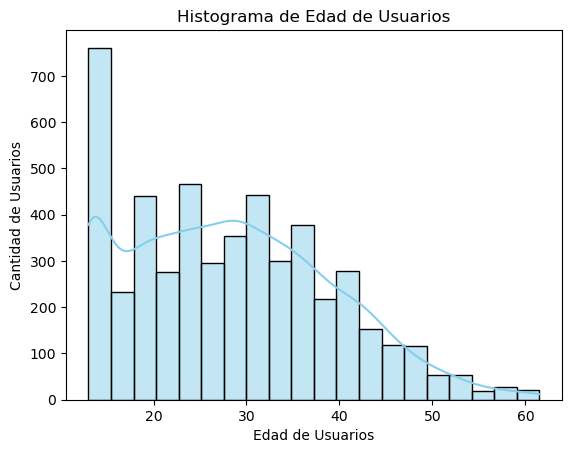

In [640]:
sns.histplot(x=usuarios['edad'], bins=20, color='skyblue', kde=True)
plt.title('Histograma de Edad de Usuarios')
plt.ylabel('Cantidad de Usuarios')
plt.xlabel('Edad de Usuarios')
plt.show()

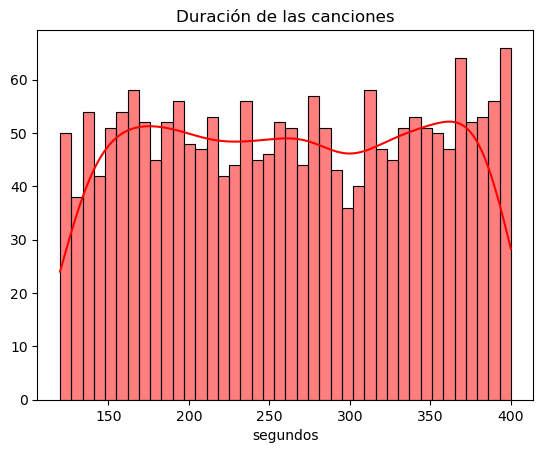

In [641]:
sns.histplot(canciones['duracion_seg'], bins=40, color = "red", kde=True)
plt.title("Duración de las canciones")
plt.xlabel("segundos")
plt.ylabel("")
plt.show()


##### 2. Boxplots

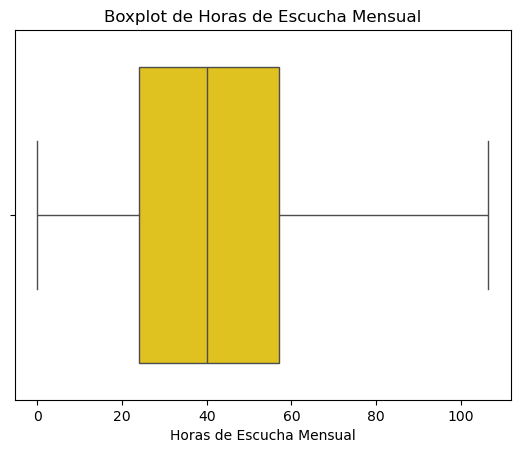

In [642]:
sns.boxplot(x=usuarios['horas_escucha_mensual'], color='gold')
plt.title('Boxplot de Horas de Escucha Mensual')
plt.xlabel('Horas de Escucha Mensual')
plt.show()

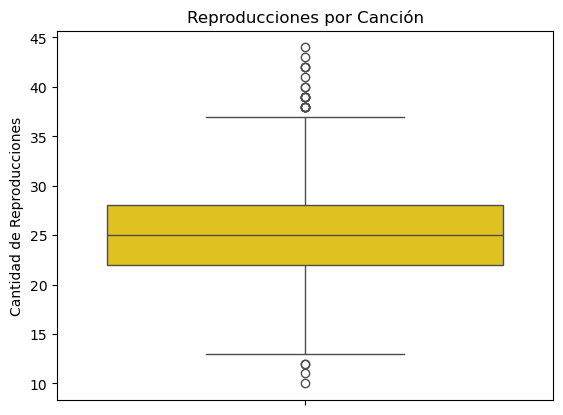

In [643]:
# Primero sacamos la cantidad de reproducciones por canción
reproducciones_por_cancion = reproducciones.groupby('cancion_id').size()

sns.boxplot(y=reproducciones_por_cancion, color='gold')
plt.title('Reproducciones por Canción')
plt.ylabel('Cantidad de Reproducciones')
plt.show()


##### 3. Multiples a la vez

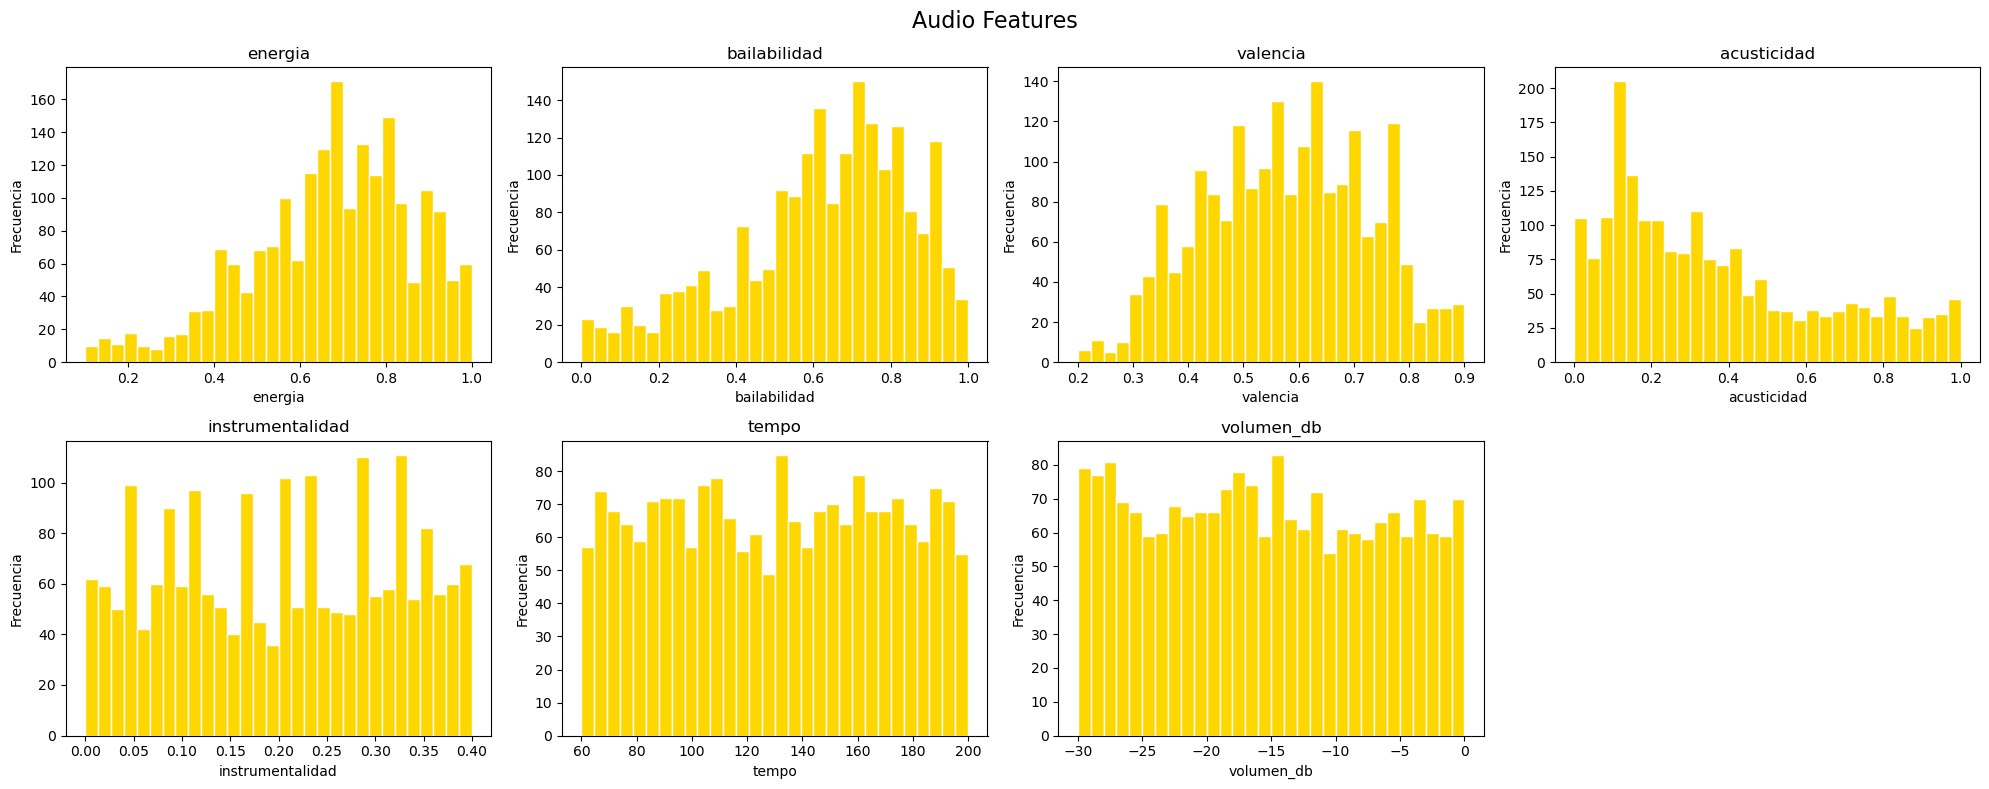

In [644]:
# Columnas a evaluar
cols = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'instrumentalidad', 'tempo', 'volumen_db']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(canciones[col], bins=30, color='gold', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False) # Esto es para quitar el ultimo subplot que está vacío
plt.suptitle('Audio Features', fontsize=16)
plt.tight_layout()
plt.show()


## 36. Matriz de Correlacion y Heatmap


##### [Índice](#Index)

<Axes: >

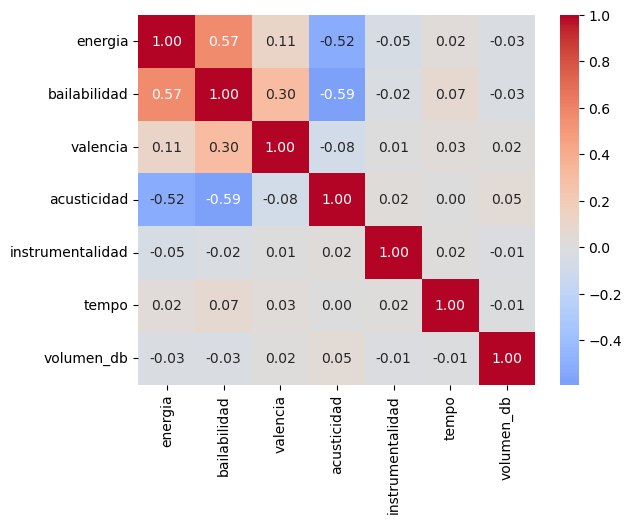

In [645]:
# Columnas numéricas para la matriz de correlación
cols_num = ['energia', 'bailabilidad', 'valencia', 'acusticidad', 'instrumentalidad', 'tempo', 'volumen_db']

# Matriz de correlación
corr_matrix = canciones[cols_num].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

In [646]:
#Buscamos las correlaciones más fuertes
correlaciones_fuertes = corr_matrix.unstack().sort_values(ascending=False)
print("Correlaciones más fuertes entre características de audio:")
for (col1, col2), corr in correlaciones_fuertes.items():
    if col1 != col2 and abs(corr) > 0.5:
        print(f"{col1} - {col2}: {corr:.2f}")



Correlaciones más fuertes entre características de audio:
energia - bailabilidad: 0.57
bailabilidad - energia: 0.57
energia - acusticidad: -0.52
acusticidad - energia: -0.52
bailabilidad - acusticidad: -0.59
acusticidad - bailabilidad: -0.59


## 37. Patrones Temporales



##### [Índice](#Index)

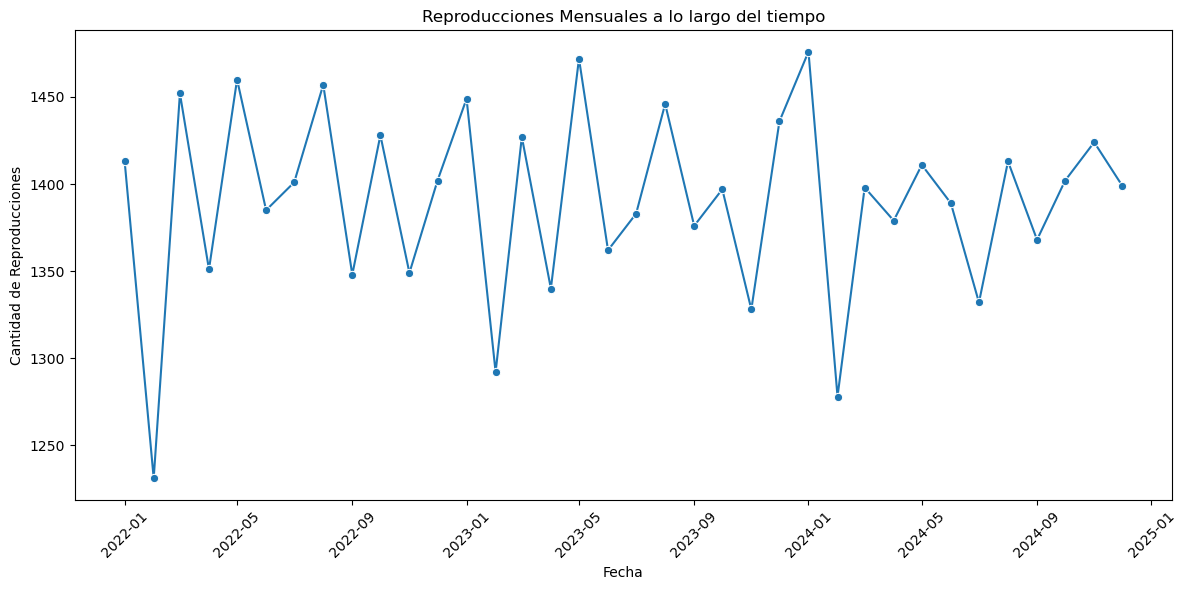

In [647]:
# 2. Serie Mensual 
# Hacemoos un gráfico de líneas para visualizar los patrones temporales de reproducciones mensuales
reproducciones_mensuales = reproducciones.groupby(reproducciones['fecha'].dt.to_period('M')).size().reset_index(name='reproducciones')
reproducciones_mensuales['fecha'] = reproducciones_mensuales['fecha'].dt.to_timestamp()  # Convertir a timestamp para el gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(data=reproducciones_mensuales, x='fecha', y='reproducciones', marker='o')
plt.title('Reproducciones Mensuales a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Reproducciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


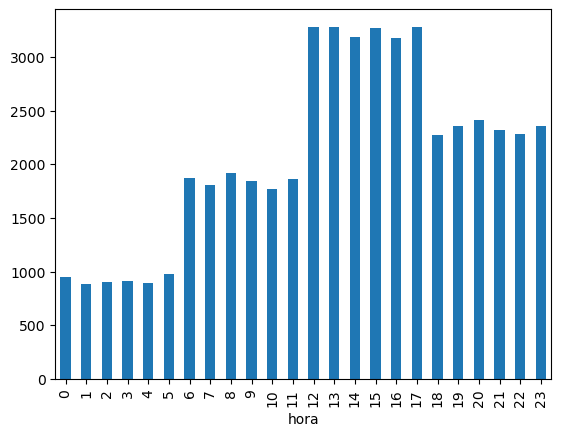

In [648]:
# 3. Patrón horario
# Analizamos el patrón de reproducciones por hora del día
reproducciones_por_hora = reproducciones.groupby('hora').size().plot(kind='bar')

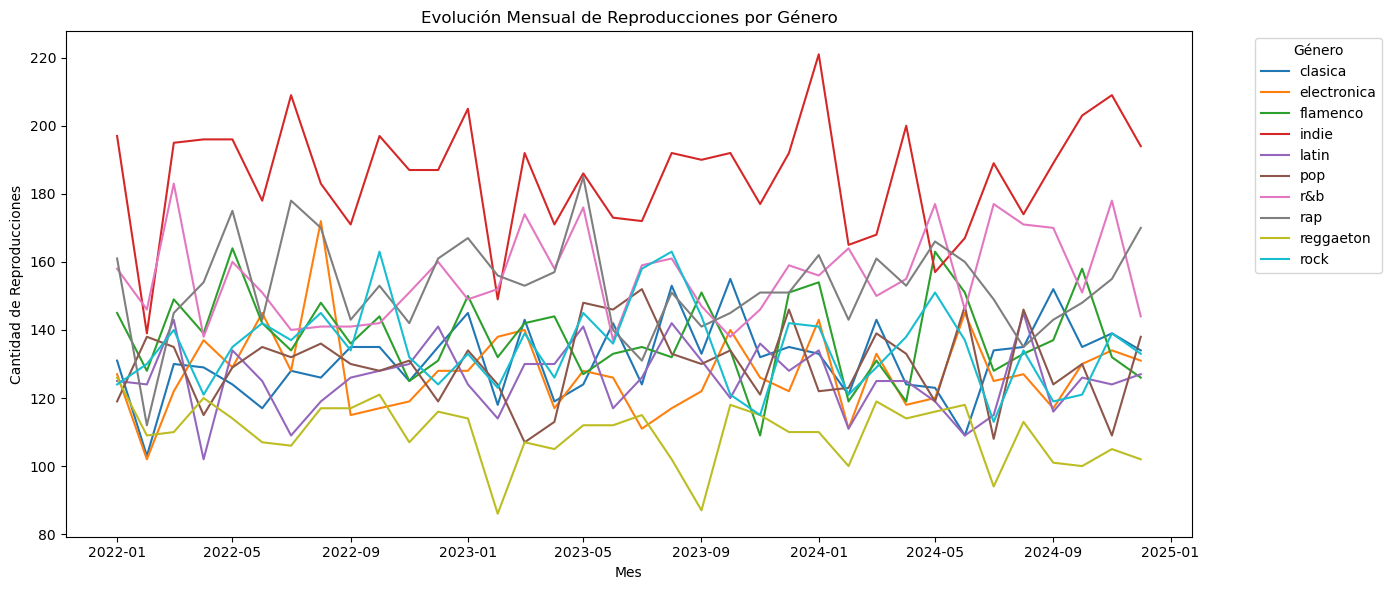

In [649]:
# Estacionalidad por género: Haz merge de reproducciones con canciones, agrupa por (mes, genero) y usa sns.lineplot con hue='genero' para ver la evolución de cada género.

# Estacionalidad por género
# Merge
rep_genero = reproducciones.merge(canciones[['cancion_id', 'genero']], on='cancion_id')
rep_genero['mes'] = rep_genero['fecha'].dt.to_period('M').dt.to_timestamp()

# Group by
rep_genero_mensual = rep_genero.groupby(['mes', 'genero']).size().reset_index(name='reproducciones')

plt.figure(figsize=(14, 6))
sns.lineplot(data=rep_genero_mensual, x='mes', y='reproducciones', hue='genero')
plt.title('Evolución Mensual de Reproducciones por Género')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Reproducciones')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Aparentemente cuando el indie sube el reggaeton baja y viceversa.


## 38. Segmentacion de Usuarios (Descriptivo)




##### [Índice](#Index)

##### 1. Grupos de edad

In [650]:
usuarios['grupos_edad'] = pd.cut(usuarios['edad'], bins=[0, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '50+'])

##### 2. Agrupar por suscripcion

In [651]:
tipo_suscripcion_horas = usuarios.groupby('tipo_suscripcion')['horas_escucha_mensual'].mean()
tipo_suscripcion_generos = usuarios.groupby('tipo_suscripcion')['sexo']
tipo_suscripcion_dispositivo = usuarios.groupby('tipo_suscripcion')['dispositivo_principal']

##### 3. Visualizacion

<Axes: xlabel='grupos_edad', ylabel='horas_escucha_mensual'>

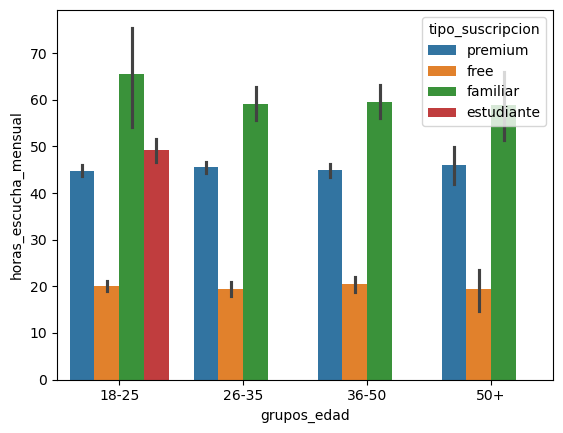

In [652]:
sns.barplot(data=usuarios, x='grupos_edad', y='horas_escucha_mensual', hue='tipo_suscripcion')

##### 4. Dispositivos

<Axes: ylabel='count'>

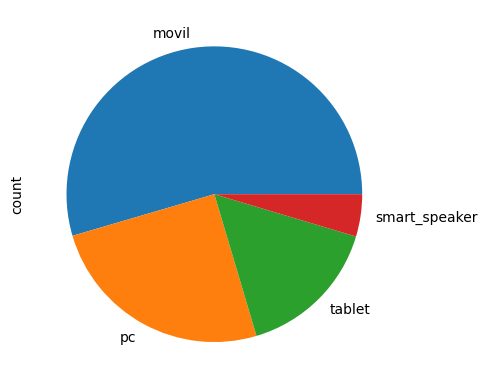

In [653]:
usuarios['dispositivo_principal'].value_counts().plot(kind='pie')

In [654]:
# Comparamos las metricas con group by
usuarios.groupby('dispositivo_principal')[['horas_escucha_mensual']].mean().round(2)


,horas_escucha_mensual
dispositivo_principal,
movil,40.59
pc,41.91
smart_speaker,42.00
tablet,40.67


## 39. Ingenieria de Features (Creativa y Requerida)





##### [Índice](#Index)

##### 1. Total_reproducciones

In [655]:
reprod_por_cancion = reproducciones.groupby('cancion_id').size().reset_index(name='total_reproducciones')
# Le hacemos un merge a canciones para añadir total_reproducciones a canciones
canciones = canciones.merge(reprod_por_cancion, on='cancion_id', how='left')


In [656]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo,volumen_db,explicito,total_reproducciones
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021-01-01,339,electronica,trance,0.86,0.63,0.38,0.13,0.24,66,-29.7,0,35
1,2,Tema 2,169,Francisco Stone - Evolución,2022-01-01,134,latin,salsa,0.64,0.87,0.60,0.26,0.22,129,-9.2,0,24
2,3,Tema 3,80,Francisco Stone - Nuevo,2022-01-01,123,pop,pop-urbano,0.66,0.58,0.78,0.17,0.13,96,-7.6,0,26
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021-01-01,135,latin,cumbia,0.83,0.91,0.80,0.43,0.04,195,-19.0,1,33
4,5,Tema 5,108,Gabriel García - Vueltas,2022-01-01,200,pop,pop-latino,0.51,0.59,0.89,0.22,0.36,139,-11.1,0,22


##### 2. Ratio_completadas

In [657]:
ratio_completadas = round(reproducciones.groupby('cancion_id')['completada'].mean(), 2)


#Hacemos el merge para añadir el ratio_completadas a canciones
canciones = canciones.merge(ratio_completadas.reset_index(name='ratio_completadas'), on='cancion_id', how='left')

In [658]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo,volumen_db,explicito,total_reproducciones,ratio_completadas
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021-01-01,339,electronica,trance,0.86,0.63,0.38,0.13,0.24,66,-29.7,0,35,0.83
1,2,Tema 2,169,Francisco Stone - Evolución,2022-01-01,134,latin,salsa,0.64,0.87,0.60,0.26,0.22,129,-9.2,0,24,0.75
2,3,Tema 3,80,Francisco Stone - Nuevo,2022-01-01,123,pop,pop-urbano,0.66,0.58,0.78,0.17,0.13,96,-7.6,0,26,0.73
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021-01-01,135,latin,cumbia,0.83,0.91,0.80,0.43,0.04,195,-19.0,1,33,0.67
4,5,Tema 5,108,Gabriel García - Vueltas,2022-01-01,200,pop,pop-latino,0.51,0.59,0.89,0.22,0.36,139,-11.1,0,22,0.91


##### 3. Antiguedad_cancion

In [659]:
#Añadimos una nueva columna de antiguedad de la canción en años
canciones['antiguedad_cancion'] = 2026 - canciones['anio_lanzamiento'].dt.year

In [660]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo,volumen_db,explicito,total_reproducciones,ratio_completadas,antiguedad_cancion
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021-01-01,339,electronica,trance,0.86,0.63,0.38,0.13,0.24,66,-29.7,0,35,0.83,5
1,2,Tema 2,169,Francisco Stone - Evolución,2022-01-01,134,latin,salsa,0.64,0.87,0.60,0.26,0.22,129,-9.2,0,24,0.75,4
2,3,Tema 3,80,Francisco Stone - Nuevo,2022-01-01,123,pop,pop-urbano,0.66,0.58,0.78,0.17,0.13,96,-7.6,0,26,0.73,4
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021-01-01,135,latin,cumbia,0.83,0.91,0.80,0.43,0.04,195,-19.0,1,33,0.67,5
4,5,Tema 5,108,Gabriel García - Vueltas,2022-01-01,200,pop,pop-latino,0.51,0.59,0.89,0.22,0.36,139,-11.1,0,22,0.91,4


##### 4. Diversidad_generos_usuario

In [661]:
reproducciones_canciones = reproducciones.merge(canciones[['cancion_id', 'genero']], on='cancion_id', how='left')
diversidad_generos_usuario = reproducciones_canciones.groupby('usuario_id')['genero'].nunique().reset_index(name='diversidad_generos_usuario')

# La añadimos a usuarios con merge
usuarios = usuarios.merge(diversidad_generos_usuario, on='usuario_id', how='left')

In [662]:
usuarios.head()

,usuario_id,edad,sexo,ciudad,tipo_suscripcion,fecha_registro,dispositivo_principal,horas_escucha_mensual,grupos_edad,diversidad_generos_usuario
0,1,40.0,M,Cádiz,premium,2021-06-22,movil,32.0,36-50,6
1,2,32.0,M,Girona,premium,2022-10-07,movil,34.0,26-35,6
2,3,30.0,M,Cádiz,premium,2019-05-22,tablet,62.0,26-35,4
3,4,13.0,No_especificado,Vigo,free,2019-11-03,pc,9.0,18-25,5
4,5,30.0,No_especificado,Granada,free,2022-07-22,tablet,56.0,26-35,5


##### 5. hora_categoria

In [663]:
reproducciones['hora_categoria'] = pd.cut(reproducciones['hora'], bins=[0,6,12,20,24], labels=['Madrugada','Mañana','Tarde','Noche'], include_lowest=True)
    

In [665]:
reproducciones.head()

,reproduccion_id,usuario_id,cancion_id,fecha,hora,duracion_escucha_seg,completada,modo_reproduccion,dispositivo,hora_categoria
0,1,1048,668,2022-11-24,8,175.0,1,busqueda,movil,Mañana
1,2,3017,1719,2024-09-09,22,242.0,0,album,tablet,Noche
2,3,370,560,2024-09-19,13,273.0,1,radio,tablet,Tarde
3,4,1515,1268,2023-09-21,9,21.0,0,album,tablet,Mañana
4,5,4837,1146,2024-09-23,7,279.0,1,busqueda,tablet,Mañana


##### 6. feature_importance_score

In [667]:
canciones['feature_importance_score'] = canciones['energia'] + canciones['bailabilidad'] - canciones['acusticidad']

In [668]:
canciones.head()

,cancion_id,titulo,artista_id,album,anio_lanzamiento,duracion_seg,genero,subgenero,energia,bailabilidad,valencia,acusticidad,instrumentalidad,tempo,volumen_db,explicito,total_reproducciones,ratio_completadas,antiguedad_cancion,feature_importance_score
0,1,Tema 1,72,Bob Marley - 25 Aniversario,2021-01-01,339,electronica,trance,0.86,0.63,0.38,0.13,0.24,66,-29.7,0,35,0.83,5,1.36
1,2,Tema 2,169,Francisco Stone - Evolución,2022-01-01,134,latin,salsa,0.64,0.87,0.60,0.26,0.22,129,-9.2,0,24,0.75,4,1.25
2,3,Tema 3,80,Francisco Stone - Nuevo,2022-01-01,123,pop,pop-urbano,0.66,0.58,0.78,0.17,0.13,96,-7.6,0,26,0.73,4,1.07
3,4,Tema 4,103,Francisco Stone - Segundo Album,2021-01-01,135,latin,cumbia,0.83,0.91,0.80,0.43,0.04,195,-19.0,1,33,0.67,5,1.31
4,5,Tema 5,108,Gabriel García - Vueltas,2022-01-01,200,pop,pop-latino,0.51,0.59,0.89,0.22,0.36,139,-11.1,0,22,0.91,4,0.88


##### 7. usuario_actividad_nivel

In [669]:
usuarios['usuario_actividad_nivel'] = pd.cut(usuarios['horas_escucha_mensual'], bins=[0,25,50,100], labels=['Baja','Media','Alta'], include_lowest=True)


In [671]:
usuarios.head()

,usuario_id,edad,sexo,ciudad,tipo_suscripcion,fecha_registro,dispositivo_principal,horas_escucha_mensual,grupos_edad,diversidad_generos_usuario,usuario_actividad_nivel
0,1,40.0,M,Cádiz,premium,2021-06-22,movil,32.0,36-50,6,Media
1,2,32.0,M,Girona,premium,2022-10-07,movil,34.0,26-35,6,Media
2,3,30.0,M,Cádiz,premium,2019-05-22,tablet,62.0,26-35,4,Alta
3,4,13.0,No_especificado,Vigo,free,2019-11-03,pc,9.0,18-25,5,Baja
4,5,30.0,No_especificado,Granada,free,2022-07-22,tablet,56.0,26-35,5,Alta
